In [ ]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

IMG_FILE_NAME = "Image4.png"
GT_CONTOUR_FILE_NAME = "orange_gt.csv"

CLASSIFY = True # Toggles the class intended for the orange image

N_DESCRIPTORS = 50 # Number of fourier descriptors computed for prediction

MAX_LEN = 3000 # maximum length a contour can be, in number of coordinates - used to get rid of entire picture wide contours
MIN_LEN = 25   # miniumum length a contour can be - used for noise resistance, sacrificing a bit of detail

INTENSITY_THRESH = 30       # Simple intensity pixel threshold i.e. all pixels with intensity lower than this are set to 0
UNKNOWN_REGION_THRESH = 0.2 # proportion of pixels from the foreground to be set to be the unknown region

DARK_THRESH = 25 # maximum intensity for a pixel to be "dark" 
PURITY_CLASSIFICATION_THRESH = 0.9 # minimum proportion of "light" pixels for a structure to be considered a ring

img = cv2.imread(IMG_FILE_NAME, cv2.IMREAD_GRAYSCALE)



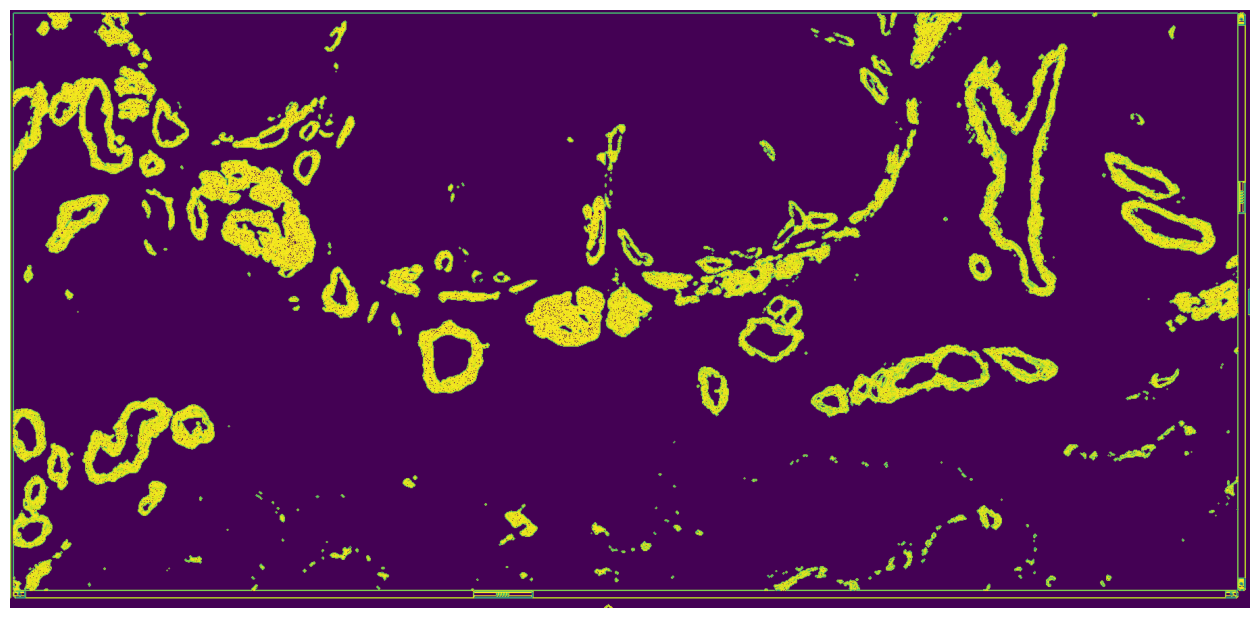

In [ ]:
# Simple pixel intensity filter
_, img = cv2.threshold(img, INTENSITY_THRESH, 255, cv2.THRESH_TOZERO)

# Laplacian filter
laplace = cv2.Laplacian(img, cv2.CV_64F)
laplace = cv2.convertScaleAbs(laplace)

_ = plt.subplots(1,1, figsize = (16,16))
plt.imshow(-laplace)
plt.axis('off')
plt.show()


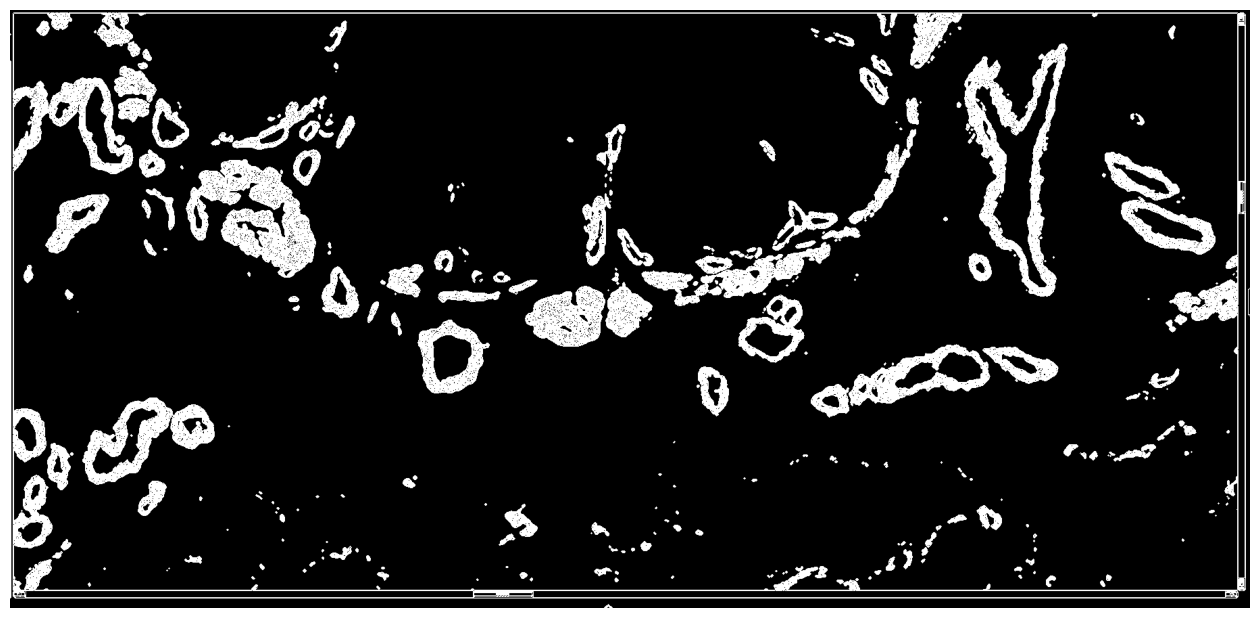

In [ ]:
# Convert to binary using Otsu threshold
_, thresh = cv2.threshold(-laplace, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
_ = plt.subplots(1,1,figsize = (16,16))
plt.imshow(thresh, cmap='gray')
plt.axis('off')
plt.show()

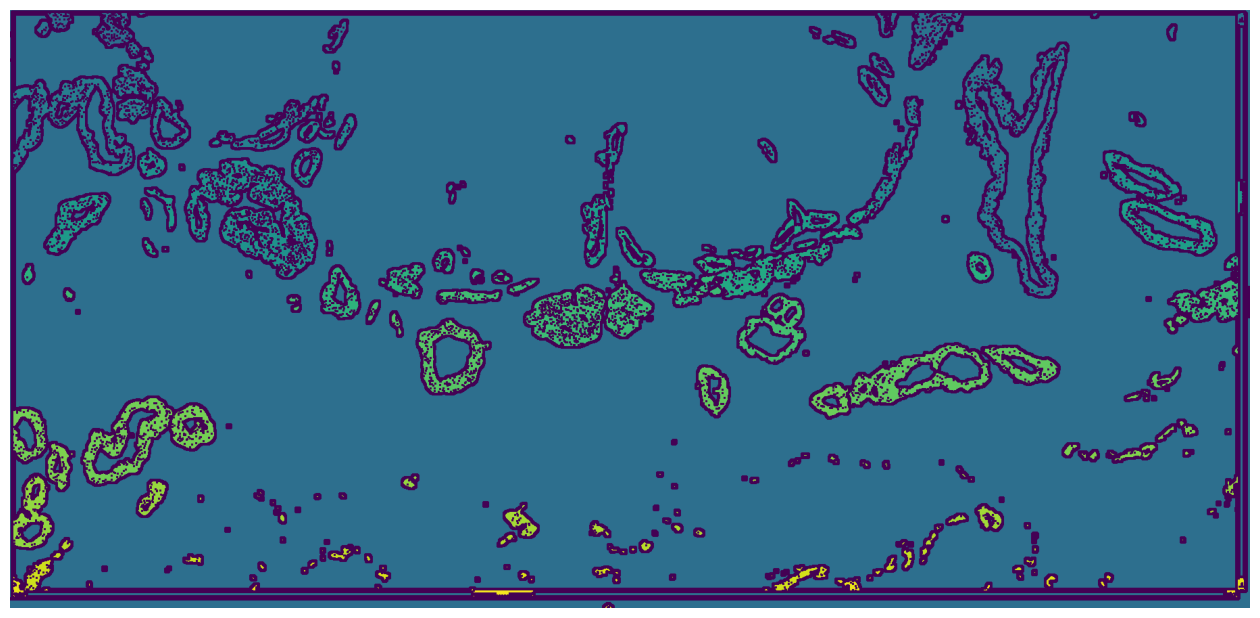

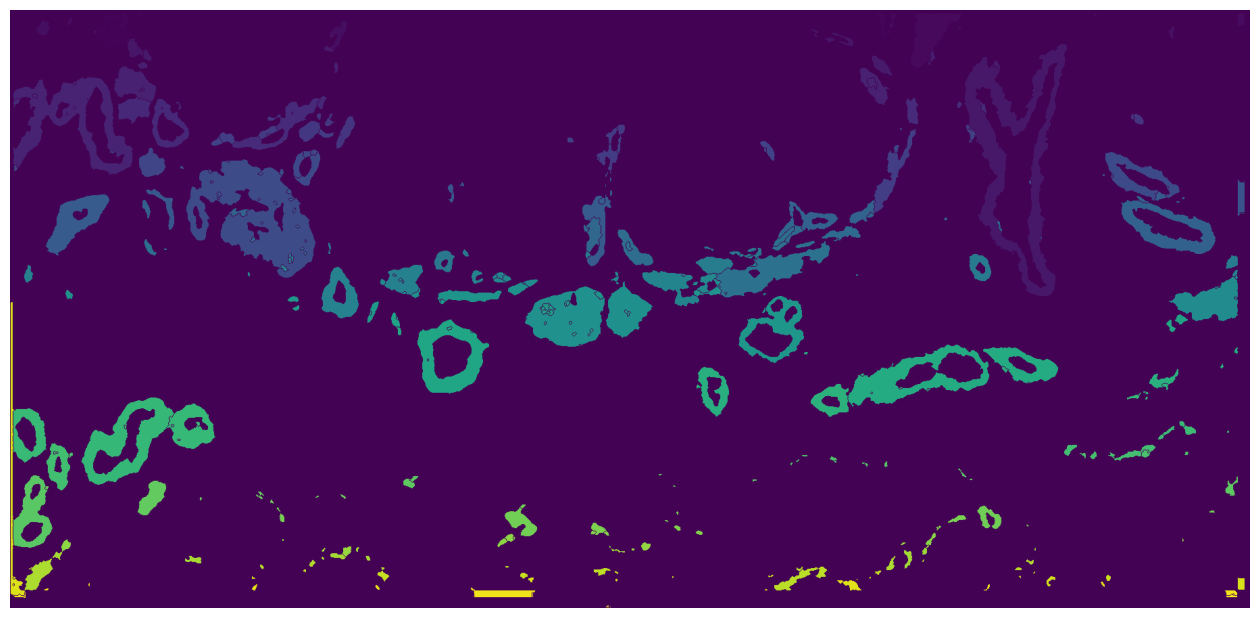

In [ ]:
# Distance transform
dist = cv2.distanceTransform(thresh, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist, UNKNOWN_REGION_THRESH * dist.max(), 255, 0)

sure_fg = np.uint8(sure_fg)


# Background region
kernel = np.ones((3,3), np.uint8)
sure_bg = cv2.dilate(thresh, kernel, iterations=3)

# Unknown region
unknown = cv2.subtract(sure_bg, sure_fg)

# Marker labelling
_, markers = cv2.connectedComponents(sure_fg) 

markers = markers + 1 
markers[unknown == 255] = 0 # unknown is marked as 0, background as 1

_ = plt.subplots(1,1,figsize = (16,16))
plt.imshow(markers-unknown)
plt.axis('off')
plt.show()


# Watershed
img_color_cvt = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
markers = cv2.watershed(img_color_cvt, markers)

_ = plt.subplots(1,1,figsize = (16,16))
plt.imshow(markers)
plt.axis('off')
plt.show()

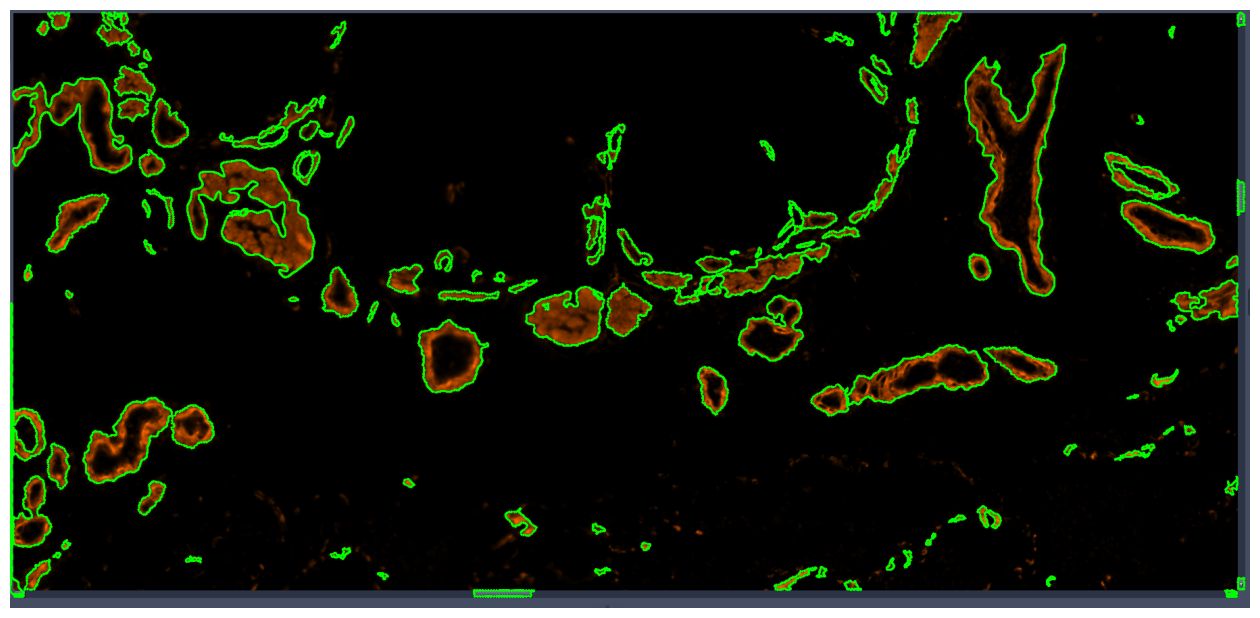

In [ ]:
# Refining the watershed model using fourier descriptors

contour_list = list()
img_color = cv2.imread(IMG_FILE_NAME,cv2.IMREAD_COLOR_RGB)

for label in np.unique(markers):
    if label == -1 or label == 1:
        continue

    mask = np.zeros_like(markers, dtype=np.uint8)
    mask[markers == label] = 255

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if len(contours) == 0:
        continue
    contour = contours[0]

    contour_complex = np.empty(contour.shape[0], dtype=complex)
    for i in range(contour.shape[0]):
        contour_complex[i] = complex(contour[i][0][0], contour[i][0][1])

    fourier_result = np.fft.fft(contour_complex)
    
    fourier_result[N_DESCRIPTORS:-N_DESCRIPTORS] = 0
    contour_reconstructed = np.fft.ifft(fourier_result)

    contour_reconstructed = np.array([[int(pt.real), int(pt.imag)] for pt in contour_reconstructed], dtype=np.int32)
    
    if len(contour_reconstructed) < MAX_LEN and len(contour_reconstructed) > MIN_LEN:
        contour_list.append(contour_reconstructed)
        cv2.drawContours(img_color, [contour_reconstructed], -1, (0, 255, 0), 2)
_,ax = plt.subplots(1,1,figsize = (16,16))
plt.imshow(img_color)
plt.axis('off')
plt.show()

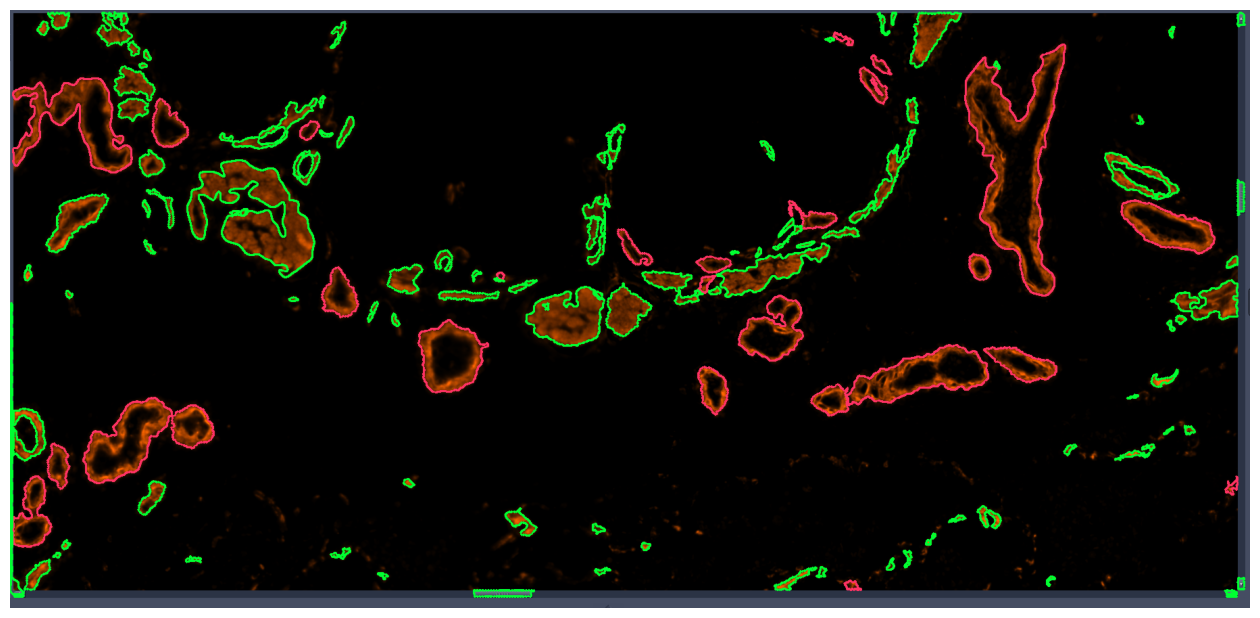

In [ ]:

def extract_pixels(contour, img):
    bounding = cv2.boundingRect(contour)
    x_to_search, y_to_search= range(bounding[0],bounding[0]+bounding[2]),range(bounding[1],bounding[1]+bounding[3])
    colour_list = list()

    for x in x_to_search:
        for y in y_to_search:
            if cv2.pointPolygonTest(contour,[x,y],measureDist=False) == 1:
                colour_list.append(img[y][x])

    return colour_list

def classify_contours(contour_list,img):
    class_list = []

    for contour in contour_list:

        colour_arr = np.array(extract_pixels(contour,img))
        if len(colour_arr) == 0:
            class_list.append(-1) # signifies an invalid contour
            continue
        
        background_count = np.bincount(colour_arr < DARK_THRESH, minlength=2)

        if background_count[0] > PURITY_CLASSIFICATION_THRESH*len(colour_arr):
            class_list.append(0) # signifies a muscle (not a ring)

        else:
            class_list.append(1) # signifies a blood vessel (ring)

    return class_list


img = cv2.imread(IMG_FILE_NAME, cv2.IMREAD_GRAYSCALE)
img_color = cv2.imread(IMG_FILE_NAME, cv2.IMREAD_COLOR_RGB) # to refresh (new image to draw on)
if CLASSIFY:
    class_list = classify_contours(contour_list, img)

    for i in range(len(class_list)):
        if class_list[i] == 0:
            cv2.drawContours(img_color, [contour_list[i]], -1, (0, 255, 50), 2) # purple if not ring
        else:
            cv2.drawContours(img_color, [contour_list[i]], -1, (255, 50, 100), 2) # green if ring

    _ = plt.subplots(1,1,figsize = (16,16))
    plt.imshow(img_color)
    plt.axis('off')
    plt.show()

In [ ]:
def filled_mask_from_contour(contour, img):
    bounding = cv2.boundingRect(contour)
    mask = np.zeros_like(img)

    x_to_search, y_to_search= range(bounding[0],bounding[0]+bounding[2]),range(bounding[1],bounding[1]+bounding[3])

    for x in x_to_search:
        for y in y_to_search:
            if cv2.pointPolygonTest(contour,[x,y],measureDist=False) in (0,1): # if inside the contour
                mask[y][x] = 1
    return mask

def describe_contours(contours:np.ndarray, img):
    contour_data = np.zeros((len(contours),4))
    if CLASSIFY:
        class_list = classify_contours(contours,img)
    else:
        class_list = [0]*len(contours)
    
    for c in range(len(contours)):
        M = cv2.moments(contours[c])
        
        contour_data[c] = [M["m10"]/(M["m00"]+1e-5), M["m01"]/(M["m00"]+1e-5), cv2.contourArea(contours[c]), class_list[c]] # +1e-5 to avoid dividing by zero
        # structure is [centroid_x, centroid_y, area, class]

    return pd.DataFrame(data = contour_data, columns=["centre_x","centre_y","area","class"]).round(3)



def result_statistics(contours, img_grey, class_id = -1): # class id  is optional, only to be used in conjunction with classify
    filled_mask = np.zeros_like(img_grey)
    contour_df = describe_contours(contours,img_grey)
    
    if class_id != -1:
        selected_contours = []
        for i in range(len(contours)):
            if contour_df.loc[i,"class"] == class_id:
                selected_contours.append(contours[i])

        contour_df = describe_contours(selected_contours,img_grey) # recompute contour_df using only one class
        output_class = f"Class {class_id}"

    else:
        output_class = "Unclassed"
        selected_contours = contours

    contour_df = contour_df[contour_df["class"] != -1] # removing invalid contours, where the length of a contour is 0, specifically a problem in the orange image

    for contour_i in selected_contours:
        filled_mask = np.logical_or(filled_mask,filled_mask_from_contour(np.array(contour_i).round(),img_grey))
    
    
    return pd.DataFrame(
        {
            "Count":len(contour_df),
            "Mean Area":contour_df["area"].mean(),
            "S.D. of Area":contour_df["area"].std(),
            "Approximate Total Area":filled_mask.sum(),
            "Proportion of Image Occupied":filled_mask.sum()/(img_grey.shape[0]*img_grey.shape[1])
        },
        index = [output_class]
    ).loc[output_class].transpose().round(4)


img_grey = cv2.imread(IMG_FILE_NAME,cv2.IMREAD_GRAYSCALE)

results_df = result_statistics(contour_list,img_grey)

if CLASSIFY:
    results_df = pd.concat((results_df, result_statistics(contour_list,img_grey,0)), axis = 1)
    results_df = pd.concat((results_df, result_statistics(contour_list,img_grey,1)), axis = 1)

results_df

,Unclassed,Class 0,Class 1
Count,143.0000,115.0000,28.0000
Mean Area,1201.6049,631.0522,3544.9464
S.D. of Area,3007.4217,1697.1680,5322.1302
Approximate Total Area,181494.0000,78956.0000,102543.0000
Proportion of Image Occupied,0.1118,0.0486,0.0631


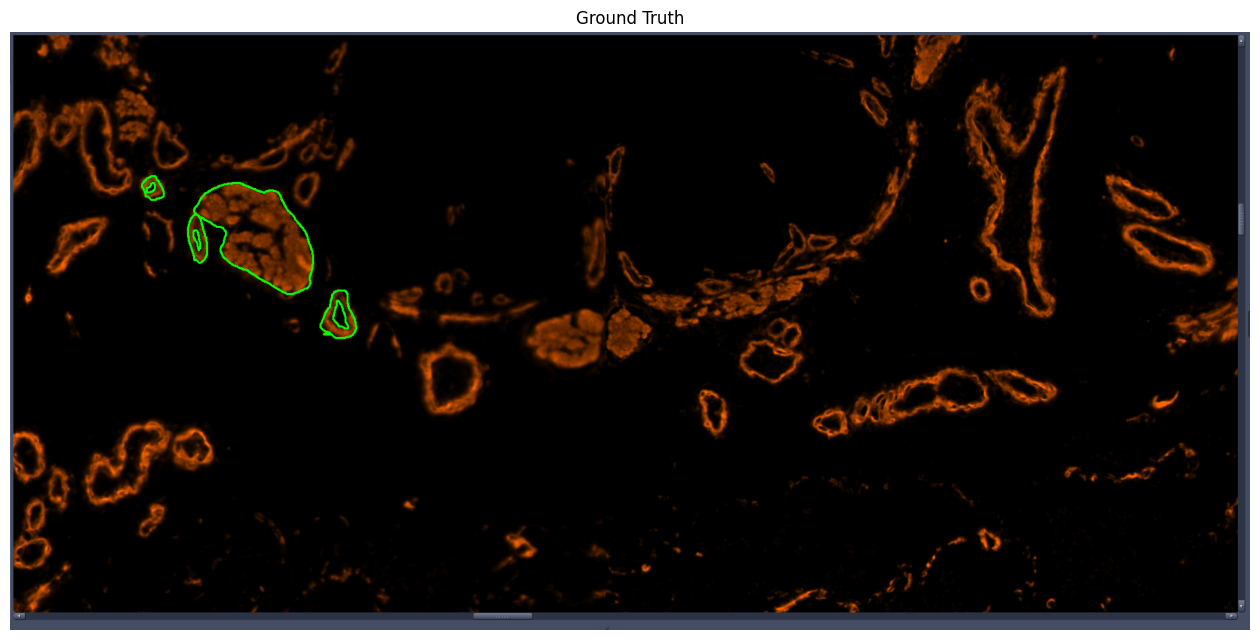

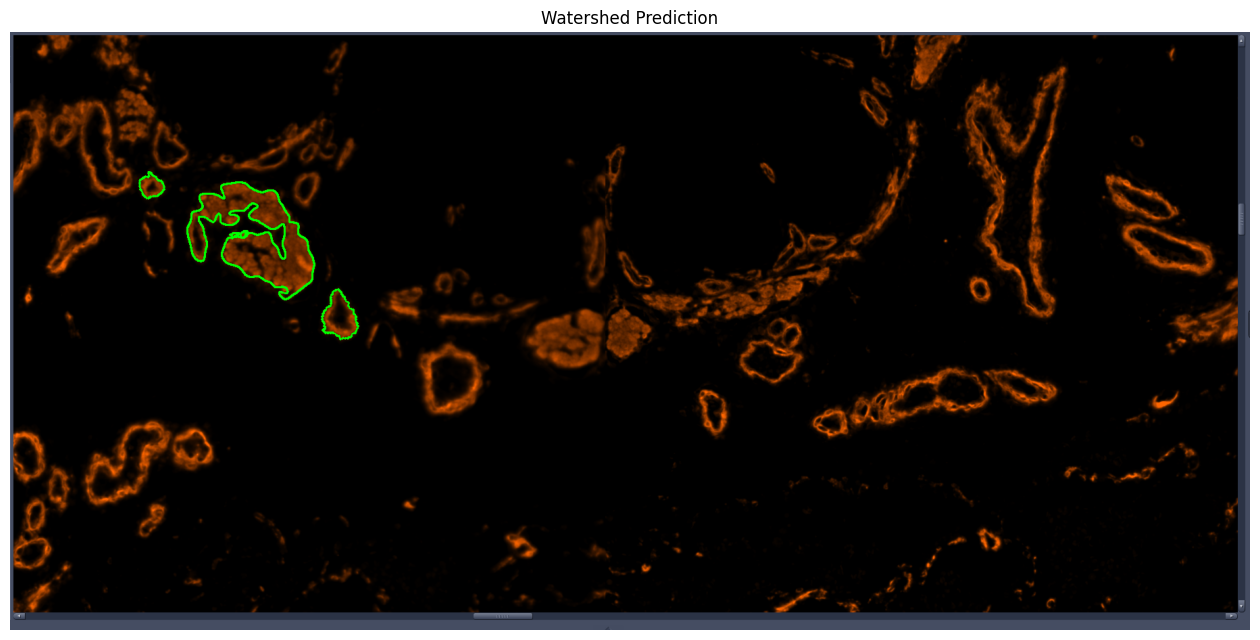

In [ ]:
gt_df = pd.read_csv(GT_CONTOUR_FILE_NAME)

gt_contour_list = []
gt_bb_list = [] # list of bounding boxes for ground truth contours

def bounding_box_contour(contour): 
    x,y,w,h = cv2.boundingRect(contour)
    box_coords = []
    for i in range(w):
        box_coords.append([x+i,y])
    for i in range(h):
        box_coords.append([x+w,y+i])
    for i in range(w):
        box_coords.append([x+w-i,y+h])
    for i in range(h):
        box_coords.append([x,y+h-i])
    return box_coords
      

img_gt = cv2.imread(IMG_FILE_NAME,cv2.IMREAD_COLOR_RGB)

gt_mask = np.zeros_like(img)
gt_bb_mask = np.zeros_like(img)

for i in gt_df["contour_id"].unique():
    current_df = gt_df[gt_df["contour_id"]==i]
    gt_contour_list.append(current_df[["x","y"]].to_numpy())
    gt_bb_list.append(np.array(bounding_box_contour(gt_contour_list[-1])))
    cv2.drawContours(img_gt, [gt_contour_list[-1]], -1, (0, 255, 0), 2)

    gt_mask = np.logical_or(gt_mask, filled_mask_from_contour(gt_contour_list[-1],img))
    gt_bb_mask = np.logical_or(gt_bb_mask, filled_mask_from_contour(gt_bb_list[-1],img))


_ = plt.subplots(1,1,figsize = (16,16))
plt.imshow(img_gt)
plt.title("Ground Truth")
plt.axis("off")
plt.show()

img_test = cv2.imread(IMG_FILE_NAME,cv2.IMREAD_COLOR_RGB)

test_contour_list = []
test_bb_list = []

test_mask = np.zeros_like(img)
test_bb_mask = np.zeros_like(img)

centres = describe_contours(contour_list,img)[["centre_x","centre_y"]].to_numpy().round() #extracts coords of the centres of watershed contours

for i in range(len(contour_list)):

    if gt_mask[int(centres[i][1])][int(centres[i][0])] == 1: # if centre of watershed contour is within the ground truth mask, they must be of the same structure
        test_contour_list.append(contour_list[i])
        test_bb_list.append(np.array(bounding_box_contour(contour_list[i])))
        cv2.drawContours(img_test, [test_contour_list[-1]], -1, (0, 255, 0), 2)

        test_mask = np.logical_or(test_mask, filled_mask_from_contour(test_contour_list[-1],img))
        test_bb_mask = np.logical_or(test_bb_mask, filled_mask_from_contour(test_bb_list[-1], img))

_ = plt.subplots(1,1,figsize = (16,16))
plt.imshow(img_test)
plt.title("Watershed Prediction")
plt.axis("off")
plt.show()

Intersection over Union = 0.8956
Dice Coefficient = 0.9449
Recall = 0.8259
Precision = 0.9517
F1 Score = 0.8844


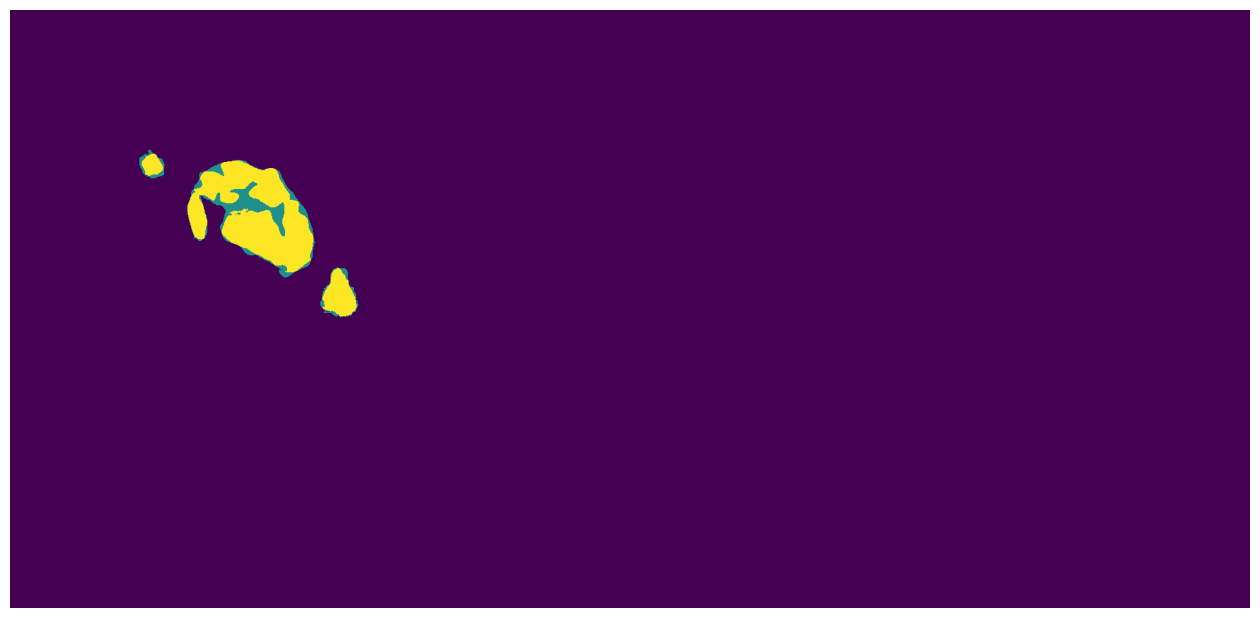

In [ ]:
def bb_iou(gt_bb_mask,test_bb_mask):
    if  np.logical_or(gt_bb_mask,test_bb_mask).sum() == 0: #protection against zero division
        return 0
    return float(np.logical_and(gt_bb_mask,test_bb_mask).sum() / np.logical_or(gt_bb_mask,test_bb_mask).sum())

def dice_coefficient(gt_bb_mask,test_bb_mask):
    if gt_bb_mask.sum() == 0 and test_bb_mask.sum() == 0:  # protection against zero division
        return 0
    return float(2* np.logical_and(gt_bb_mask,test_bb_mask).sum() / (gt_bb_mask.sum() + test_bb_mask.sum()))

def classical_metrics(gt_mask,test_mask):
    tp = np.logical_and(gt_mask,test_mask).sum()
    fp = np.logical_and(np.logical_not(gt_mask), test_mask).sum()
    fn = np.logical_and(gt_mask, np.logical_not(test_mask)).sum()

    if tp == 0:
        return (0,0,0)
    recall = tp/(tp+fn)
    precision = tp/(tp+fp)
    f1_score = 2*precision*recall/(precision+recall)
    return (recall,precision,f1_score)


print(f"Intersection over Union = {bb_iou(gt_bb_mask,test_bb_mask):.4f}")
print(f"Dice Coefficient = {dice_coefficient(gt_bb_mask,test_bb_mask):.4f}")
metric_values = classical_metrics(gt_mask,test_mask)
print(f"Recall = {metric_values[0]:.4f}\nPrecision = {metric_values[1]:.4f}\nF1 Score = {metric_values[2]:.4f}")

_ = plt.subplots(1,1,figsize = (16,16))
plt.imshow(np.add(2*gt_mask,2*test_mask))
plt.axis("off")
plt.show()
